In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import warnings
warnings.filterwarnings("ignore")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import pandas as pd

file_path = "C:/Users/as958/OneDrive/Desktop/ey class sep/Blinkit Dark Store Expansion/03_Blinkit_Dark_Store_Network_Synthetic_Dataset.xlsx"

df = pd.read_excel(
    file_path,
    sheet_name="Daily_Store_Performance"
)

print(df.shape)
print(df.head())

(32760, 38)
  Record_ID       Date Store_ID       City  Store_Format  Maturity_Months  \
0  R0000001 2025-01-01    DS001  Delhi NCR  Mature Mixed               32   
1  R0000002 2025-01-01    DS002     Mumbai    New Growth                8   
2  R0000003 2025-01-01    DS003  Bengaluru  Mature Mixed               22   
3  R0000004 2025-01-01    DS004  Hyderabad  Mature Mixed               44   
4  R0000005 2025-01-01    DS005       Pune  Mature Dense               31   

   Sessions  Orders  Conversion_Rate  Peak_Order_Share  ...  Complaint_Rate  \
0      1122     267         0.238094          0.234957  ...        0.010193   
1       641     178         0.278352          0.410390  ...        0.008006   
2      1080     262         0.242722          0.329824  ...        0.021947   
3      1032     310         0.301002          0.333577  ...        0.026999   
4      1124     397         0.353484          0.438616  ...        0.011945   

   Refund_Cost_INR  Average_Rating_5  Repeat_Order

In [5]:
df = pd.read_excel(
    file_path,
    sheet_name="Daily_Store_Performance"
)

store_master = pd.read_excel(
    file_path,
    sheet_name="Dark_Store_Master"
)

data_dictionary = pd.read_excel(
    file_path,
    sheet_name="Data_Dictionary"
)

print("Daily Performance:", df.shape)
print("Store Master:", store_master.shape)
print("Data Dictionary:", data_dictionary.shape)

Daily Performance: (32760, 38)
Store Master: (60, 7)
Data Dictionary: (38, 2)


In [6]:
df.head()

,Record_ID,Date,Store_ID,City,Store_Format,Maturity_Months,Sessions,Orders,Conversion_Rate,Peak_Order_Share,...,Complaint_Rate,Refund_Cost_INR,Average_Rating_5,Repeat_Order_Rate,Estimated_Category_Margin_INR,Delivery_Cost_INR,Store_Variable_Cost_INR,Contribution_INR,Contribution_Per_Order_INR,Capacity_Utilisation_Rate
0,R0000001,2025-01-01,DS001,Delhi NCR,Mature Mixed,32,1122,267,0.238094,0.234957,...,0.010193,1538.155736,4.696720,0.858433,38300.848076,11373.931210,12938.340089,18835.789835,70.546029,0.861290
1,R0000002,2025-01-01,DS002,Mumbai,New Growth,8,641,178,0.278352,0.410390,...,0.008006,685.758721,4.985398,0.920000,24432.816474,5511.855806,10208.191802,12086.573614,67.902099,0.809091
2,R0000003,2025-01-01,DS003,Bengaluru,Mature Mixed,22,1080,262,0.242722,0.329824,...,0.021947,2131.964278,4.596525,0.724568,32909.925549,8563.888257,8499.484189,17186.015436,65.595479,0.845161
3,R0000004,2025-01-01,DS004,Hyderabad,Mature Mixed,44,1032,310,0.301002,0.333577,...,0.026999,2650.937002,4.539683,0.789817,25650.653721,10437.478454,6330.789724,9515.360474,30.694711,1.000000
4,R0000005,2025-01-01,DS005,Pune,Mature Dense,31,1124,397,0.353484,0.438616,...,0.011945,2386.949941,4.558536,0.775030,68009.479225,17000.384293,14707.142269,38461.850070,96.881234,1.017949


In [7]:
df.tail()

,Record_ID,Date,Store_ID,City,Store_Format,Maturity_Months,Sessions,Orders,Conversion_Rate,Peak_Order_Share,...,Complaint_Rate,Refund_Cost_INR,Average_Rating_5,Repeat_Order_Rate,Estimated_Category_Margin_INR,Delivery_Cost_INR,Store_Variable_Cost_INR,Contribution_INR,Contribution_Per_Order_INR,Capacity_Utilisation_Rate
32755,R0032756,2026-06-30,DS056,Mumbai,Mature Dense,33,771,299,0.388263,0.462946,...,0.003000,726.044443,4.658783,0.761111,30152.650155,8456.677094,9173.536994,18558.371970,62.068134,0.766667
32756,R0032757,2026-06-30,DS057,Bengaluru,New Growth,47,538,151,0.281783,0.355422,...,0.009597,666.494991,4.824185,0.753864,21300.281180,5785.554258,8204.396566,9955.636286,65.931366,0.686364
32757,R0032758,2026-06-30,DS058,Hyderabad,Mature Dense,41,1080,292,0.271174,0.427234,...,0.009165,1125.973386,4.914830,0.830864,25314.411357,9127.521834,7437.162141,10444.918339,35.770268,0.748718
32758,R0032759,2026-06-30,DS059,Pune,Mature Dense,3,1182,423,0.357964,0.388771,...,0.018290,2441.940370,4.741865,0.781651,51873.159933,16743.851435,8304.685338,32023.333966,75.705281,1.084615
32759,R0032760,2026-06-30,DS060,Kolkata,Mature Mixed,41,812,190,0.235164,0.458459,...,0.012537,1150.496515,4.389512,0.779932,24757.928544,5192.327192,8303.421644,14121.465045,74.323500,0.612903


In [8]:
df.columns.tolist()

['Record_ID',
 'Date',
 'Store_ID',
 'City',
 'Store_Format',
 'Maturity_Months',
 'Sessions',
 'Orders',
 'Conversion_Rate',
 'Peak_Order_Share',
 'Average_Order_Value_INR',
 'Gross_Order_Value_INR',
 'Discounts_INR',
 'Net_Order_Value_INR',
 'Delivery_Fee_INR',
 'Pick_Time_Min',
 'Pack_Time_Min',
 'Handover_Time_Min',
 'Delivery_Time_Min',
 'Promised_Time_Hit_Rate',
 'In_Stock_Rate',
 'Stockout_Events',
 'SKU_Count',
 'Inventory_Value_INR',
 'Wastage_INR',
 'Picker_Hours',
 'Delivery_Partner_Hours',
 'Cancellation_Rate',
 'Complaint_Rate',
 'Refund_Cost_INR',
 'Average_Rating_5',
 'Repeat_Order_Rate',
 'Estimated_Category_Margin_INR',
 'Delivery_Cost_INR',
 'Store_Variable_Cost_INR',
 'Contribution_INR',
 'Contribution_Per_Order_INR',
 'Capacity_Utilisation_Rate']

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32760 entries, 0 to 32759
Data columns (total 38 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   Record_ID                      32760 non-null  object        
 1   Date                           32760 non-null  datetime64[ns]
 2   Store_ID                       32760 non-null  object        
 3   City                           32760 non-null  object        
 4   Store_Format                   32760 non-null  object        
 5   Maturity_Months                32760 non-null  int64         
 6   Sessions                       32760 non-null  int64         
 7   Orders                         32760 non-null  int64         
 8   Conversion_Rate                32760 non-null  float64       
 9   Peak_Order_Share               32760 non-null  float64       
 10  Average_Order_Value_INR        32760 non-null  float64       
 11  Gross_Order_Val

In [10]:
df.describe()

,Date,Maturity_Months,Sessions,Orders,Conversion_Rate,Peak_Order_Share,Average_Order_Value_INR,Gross_Order_Value_INR,Discounts_INR,Net_Order_Value_INR,...,Complaint_Rate,Refund_Cost_INR,Average_Rating_5,Repeat_Order_Rate,Estimated_Category_Margin_INR,Delivery_Cost_INR,Store_Variable_Cost_INR,Contribution_INR,Contribution_Per_Order_INR,Capacity_Utilisation_Rate
count,32760,32760.000000,32760.000000,32760.000000,32760.000000,32760.000000,32760.000000,32760.000000,32760.000000,32760.000000,...,32760.000000,32760.000000,32760.000000,32760.000000,32760.000000,32760.000000,32760.000000,32760.000000,32760.000000,32760.000000
mean,2025-09-30 12:00:00.000000256,27.416667,967.122375,296.002137,0.302264,0.412765,603.119850,180298.566637,14095.704092,166202.862544,...,0.015777,1789.838190,4.523364,0.774752,37407.201734,9705.427366,8820.041344,21811.452924,68.188011,0.889712
min,2025-01-01 00:00:00,3.000000,162.000000,45.000000,0.120000,0.220000,320.000000,22477.065045,1180.154412,20604.160913,...,0.003000,60.429135,3.182997,0.543817,4885.296839,1208.056998,3126.603167,-7581.031753,-102.187143,0.300000
25%,2025-05-17 00:00:00,16.750000,731.000000,204.000000,0.269620,0.363949,543.965872,118202.068901,8699.655928,108190.590580,...,0.010111,884.233896,4.371932,0.736331,23952.249819,6468.305743,6706.902392,10902.846923,48.799316,0.741935
50%,2025-09-30 12:00:00,28.500000,954.000000,278.000000,0.302213,0.410705,603.232808,163176.095817,12346.231216,150651.146011,...,0.014951,1394.214976,4.533312,0.775098,33595.874815,8944.033713,8547.536359,18845.742485,68.382860,0.893548
75%,2026-02-14 00:00:00,41.000000,1170.000000,370.000000,0.334515,0.459707,661.989329,228292.900366,17723.148133,211133.107636,...,0.020414,2283.525804,4.688335,0.814025,47469.274406,12172.648319,10636.177630,29825.840363,88.230436,1.066667
max,2026-06-30 00:00:00,48.000000,2199.000000,854.000000,0.491046,0.650000,971.587464,681585.963268,76652.938290,620359.686470,...,0.056923,11615.313648,5.000000,0.920000,140069.061781,34464.017836,20780.423353,112623.591987,177.319680,1.150000
std,NaN,13.234364,308.319261,118.768442,0.048498,0.070101,87.062338,82324.881731,7629.078409,76705.316606,...,0.007930,1301.655065,0.236916,0.057174,17967.614107,4300.069744,2707.776476,14883.780082,30.131272,0.195208


Data audit

In [11]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 32760
Columns: 38


In [12]:
df.dtypes

Record_ID                                object
Date                             datetime64[ns]
Store_ID                                 object
City                                     object
Store_Format                             object
Maturity_Months                           int64
Sessions                                  int64
Orders                                    int64
Conversion_Rate                         float64
Peak_Order_Share                        float64
Average_Order_Value_INR                 float64
Gross_Order_Value_INR                   float64
Discounts_INR                           float64
Net_Order_Value_INR                     float64
Delivery_Fee_INR                        float64
Pick_Time_Min                           float64
Pack_Time_Min                           float64
Handover_Time_Min                       float64
Delivery_Time_Min                       float64
Promised_Time_Hit_Rate                  float64
In_Stock_Rate                           

In [13]:
missing = df.isnull().sum()

missing_df = pd.DataFrame({
    "Missing_Count": missing,
    "Missing_Percentage": (missing / len(df)) * 100
})

missing_df.sort_values(
    "Missing_Count",
    ascending=False
)

,Missing_Count,Missing_Percentage
Record_ID,0,0.0
Date,0,0.0
Store_ID,0,0.0
City,0,0.0
Store_Format,0,0.0
Maturity_Months,0,0.0
Sessions,0,0.0
Orders,0,0.0
Conversion_Rate,0,0.0
Peak_Order_Share,0,0.0


In [14]:
print(
    "Duplicate rows:",
    df.duplicated().sum()
)

Duplicate rows: 0


In [15]:
print(
    "Duplicate Record IDs:",
    df["Record_ID"].duplicated().sum()
)

Duplicate Record IDs: 0


In [16]:
duplicate_store_date = df.duplicated(
    subset=["Store_ID", "Date"]
).sum()

print(
    "Duplicate Store-Date combinations:",
    duplicate_store_date
)

Duplicate Store-Date combinations: 0


Understand the network

In [17]:
print(
    "Number of stores:",
    df["Store_ID"].nunique()
)

Number of stores: 60


In [18]:
df.groupby("City")["Store_ID"].nunique().sort_values(
    ascending=False
)

City
Bengaluru    10
Delhi NCR    10
Hyderabad    10
Kolkata      10
Mumbai       10
Pune         10
Name: Store_ID, dtype: int64

In [19]:
df["Store_Format"].value_counts()

Store_Format
Mature Mixed    15834
Mature Dense     9828
New Growth       7098
Name: count, dtype: int64

In [20]:
store_master["Neighbourhood_Type"].value_counts()

Neighbourhood_Type
Student        19
Residential    17
Mixed Use      14
Office         10
Name: count, dtype: int64

In [21]:
df["Date"] = pd.to_datetime(df["Date"])

print("Start date:", df["Date"].min())
print("End date:", df["Date"].max())

print("Number of days:", df["Date"].nunique())

Start date: 2025-01-01 00:00:00
End date: 2026-06-30 00:00:00
Number of days: 546


In [22]:
store_days = df.groupby("Store_ID")["Date"].nunique()

store_days.describe()

count     60.0
mean     546.0
std        0.0
min      546.0
25%      546.0
50%      546.0
75%      546.0
max      546.0
Name: Date, dtype: float64

In [23]:
print("Minimum days per store:", store_days.min())
print("Maximum days per store:", store_days.max())

Minimum days per store: 546
Maximum days per store: 546


In [24]:
store_days[store_days < df["Date"].nunique()]

Series([], Name: Date, dtype: int64)

In [25]:
master_cols = [
    "Store_ID",
    "City",
    "Store_Format",
    "Maturity_Months"
]

master_check = store_master[master_cols].drop_duplicates()

merged_check = df.merge(
    master_check,
    on="Store_ID",
    suffixes=("_daily", "_master")
)

print(
    "City mismatches:",
    (merged_check["City_daily"] != merged_check["City_master"]).sum()
)

print(
    "Format mismatches:",
    (merged_check["Store_Format_daily"] != merged_check["Store_Format_master"]).sum()
)

print(
    "Maturity mismatches:",
    (merged_check["Maturity_Months_daily"] != merged_check["Maturity_Months_master"]).sum()
)

City mismatches: 0
Format mismatches: 0
Maturity mismatches: 0


In [26]:
rate_columns = [
    "Conversion_Rate",
    "Peak_Order_Share",
    "Promised_Time_Hit_Rate",
    "In_Stock_Rate",
    "Cancellation_Rate",
    "Complaint_Rate",
    "Repeat_Order_Rate"
]

for col in rate_columns:
    print(
        f"{col}:",
        "Min =", df[col].min(),
        "| Max =", df[col].max()
    )

Conversion_Rate: Min = 0.12 | Max = 0.4910462331873051
Peak_Order_Share: Min = 0.22 | Max = 0.65
Promised_Time_Hit_Rate: Min = 0.5920362137135847 | Max = 0.995
In_Stock_Rate: Min = 0.8597398869369284 | Max = 0.999
Cancellation_Rate: Min = 0.008 | Max = 0.09435370295206574
Complaint_Rate: Min = 0.003 | Max = 0.05692261374077279
Repeat_Order_Rate: Min = 0.5438170576920017 | Max = 0.92


In [27]:
print(
    df["Capacity_Utilisation_Rate"].describe()
)

count    32760.000000
mean         0.889712
std          0.195208
min          0.300000
25%          0.741935
50%          0.893548
75%          1.066667
max          1.150000
Name: Capacity_Utilisation_Rate, dtype: float64


In [28]:
over_capacity = df[
    df["Capacity_Utilisation_Rate"] > 1
]

print("Records above 100% capacity:",
      len(over_capacity))

Records above 100% capacity: 10928


Financial validation

In [29]:
df["Calculated_NOV"] = (
    df["Gross_Order_Value_INR"]
    - df["Discounts_INR"]
)

df["NOV_Difference"] = (
    df["Net_Order_Value_INR"]
    - df["Calculated_NOV"]
)

print(
    "Maximum NOV difference:",
    df["NOV_Difference"].abs().max()
)

Maximum NOV difference: 1.7462298274040222e-10


In [30]:
df["Calculated_AOV"] = (
    df["Gross_Order_Value_INR"]
    / df["Orders"]
)

df["AOV_Difference"] = (
    df["Average_Order_Value_INR"]
    - df["Calculated_AOV"]
)

print(
    "Maximum AOV difference:",
    df["AOV_Difference"].abs().max()
)

Maximum AOV difference: 4.547473508864641e-13


In [31]:
df["Calculated_Contribution_Per_Order"] = (
    df["Contribution_INR"] / df["Orders"]
)

df["Contribution_Difference"] = (
    df["Contribution_Per_Order_INR"]
    - df["Calculated_Contribution_Per_Order"]
)

print(
    "Maximum contribution/order difference:",
    df["Contribution_Difference"].abs().max()
)

Maximum contribution/order difference: 1.1368683772161603e-13


In [32]:
analysis_df = df.copy()

print(
    analysis_df.shape
)

(32760, 44)


In [33]:
analysis_df["Total_Fulfilment_Time_Min"] = (
    analysis_df["Pick_Time_Min"]
    + analysis_df["Pack_Time_Min"]
    + analysis_df["Handover_Time_Min"]
    + analysis_df["Delivery_Time_Min"]
)

analysis_df["Discount_Rate"] = (
    analysis_df["Discounts_INR"]
    / analysis_df["Gross_Order_Value_INR"]
)

analysis_df["Delivery_Cost_Per_Order"] = (
    analysis_df["Delivery_Cost_INR"]
    / analysis_df["Orders"]
)

analysis_df["Wastage_Rate"] = (
    analysis_df["Wastage_INR"]
    / analysis_df["Inventory_Value_INR"]
)

analysis_df["Stockout_Per_100_Orders"] = (
    analysis_df["Stockout_Events"]
    / analysis_df["Orders"]
) * 100

In [34]:
analysis_df[
    [
        "Total_Fulfilment_Time_Min",
        "Discount_Rate",
        "Delivery_Cost_Per_Order",
        "Wastage_Rate",
        "Stockout_Per_100_Orders"
    ]
].describe()

,Total_Fulfilment_Time_Min,Discount_Rate,Delivery_Cost_Per_Order,Wastage_Rate,Stockout_Per_100_Orders
count,32760.000000,32760.000000,32760.000000,32760.000000,32760.000000
mean,15.992243,0.080493,32.798683,0.003532,2.352894
std,2.591788,0.026705,5.801082,0.001468,0.989886
min,8.322916,0.020000,21.302056,0.001000,0.000000
25%,14.127555,0.061804,28.462245,0.002270,1.694915
50%,15.824001,0.079985,32.207509,0.003521,2.371542
75%,17.776934,0.098451,36.606947,0.004777,3.030303
max,25.372652,0.180000,49.846021,0.007498,7.812500


Network descriptive analysis

In [35]:
network_summary = pd.DataFrame({
    "Total Sessions": [analysis_df["Sessions"].sum()],
    "Total Orders": [analysis_df["Orders"].sum()],
    "Total GOV": [analysis_df["Gross_Order_Value_INR"].sum()],
    "Total NOV": [analysis_df["Net_Order_Value_INR"].sum()],
    "Total Contribution": [analysis_df["Contribution_INR"].sum()],
    "Average Repeat Rate": [analysis_df["Repeat_Order_Rate"].mean()],
    "Average In-Stock Rate": [analysis_df["In_Stock_Rate"].mean()],
    "Average Promised-Time Hit Rate": [analysis_df["Promised_Time_Hit_Rate"].mean()]
})

network_summary

,Total Sessions,Total Orders,Total GOV,Total NOV,Total Contribution,Average Repeat Rate,Average In-Stock Rate,Average Promised-Time Hit Rate
0,31682929,9697030,5.906581e+09,5.444806e+09,7.145432e+08,0.774752,0.9463,0.878169


In [36]:
city_summary = analysis_df.groupby("City").agg(
    Stores=("Store_ID", "nunique"),
    Sessions=("Sessions", "sum"),
    Orders=("Orders", "sum"),
    GOV=("Gross_Order_Value_INR", "sum"),
    Contribution=("Contribution_INR", "sum"),
    Avg_Repeat=("Repeat_Order_Rate", "mean"),
    Avg_InStock=("In_Stock_Rate", "mean"),
    Avg_Delivery_Time=("Delivery_Time_Min", "mean"),
    Avg_Contribution_Per_Order=("Contribution_Per_Order_INR", "mean")
).reset_index()

city_summary

,City,Stores,Sessions,Orders,GOV,Contribution,Avg_Repeat,Avg_InStock,Avg_Delivery_Time,Avg_Contribution_Per_Order
0,Bengaluru,10,5315667,1624672,9.897452e+08,1.208971e+08,0.774518,0.946451,9.469948,68.938827
1,Delhi NCR,10,5116928,1563665,9.545050e+08,1.141511e+08,0.775181,0.946650,9.426415,66.272955
2,Hyderabad,10,4519698,1337524,7.984610e+08,8.914209e+07,0.776095,0.948594,9.256454,61.176249
3,Kolkata,10,5917452,1860325,1.148033e+09,1.444188e+08,0.772236,0.944084,9.720313,73.636145
4,Mumbai,10,5507818,1685690,1.027222e+09,1.263348e+08,0.775875,0.945737,9.516264,70.823718
5,Pune,10,5305366,1625154,9.886154e+08,1.195993e+08,0.774606,0.946284,9.504960,68.280172


In [37]:
city_summary.sort_values(
    "Contribution",
    ascending=False
)

,City,Stores,Sessions,Orders,GOV,Contribution,Avg_Repeat,Avg_InStock,Avg_Delivery_Time,Avg_Contribution_Per_Order
3,Kolkata,10,5917452,1860325,1.148033e+09,1.444188e+08,0.772236,0.944084,9.720313,73.636145
4,Mumbai,10,5507818,1685690,1.027222e+09,1.263348e+08,0.775875,0.945737,9.516264,70.823718
0,Bengaluru,10,5315667,1624672,9.897452e+08,1.208971e+08,0.774518,0.946451,9.469948,68.938827
5,Pune,10,5305366,1625154,9.886154e+08,1.195993e+08,0.774606,0.946284,9.504960,68.280172
1,Delhi NCR,10,5116928,1563665,9.545050e+08,1.141511e+08,0.775181,0.946650,9.426415,66.272955
2,Hyderabad,10,4519698,1337524,7.984610e+08,8.914209e+07,0.776095,0.948594,9.256454,61.176249


In [38]:
store_summary = analysis_df.groupby(
    ["Store_ID", "City", "Store_Format"]
).agg(
    Sessions=("Sessions", "sum"),
    Orders=("Orders", "sum"),
    GOV=("Gross_Order_Value_INR", "sum"),
    NOV=("Net_Order_Value_INR", "sum"),
    Contribution=("Contribution_INR", "sum"),
    Avg_Repeat=("Repeat_Order_Rate", "mean"),
    Avg_InStock=("In_Stock_Rate", "mean"),
    Avg_Promised_Hit=("Promised_Time_Hit_Rate", "mean"),
    Avg_Delivery_Time=("Delivery_Time_Min", "mean"),
    Avg_Cancellation=("Cancellation_Rate", "mean"),
    Avg_Complaint=("Complaint_Rate", "mean"),
    Avg_Capacity=("Capacity_Utilisation_Rate", "mean"),
    Avg_Contribution_Per_Order=("Contribution_Per_Order_INR", "mean")
).reset_index()

store_summary.head()

,Store_ID,City,Store_Format,Sessions,Orders,GOV,NOV,Contribution,Avg_Repeat,Avg_InStock,Avg_Promised_Hit,Avg_Delivery_Time,Avg_Cancellation,Avg_Complaint,Avg_Capacity,Avg_Contribution_Per_Order
0,DS001,Delhi NCR,Mature Mixed,511812,149074,8.784943e+07,8.129663e+07,1.023345e+07,0.779669,0.947348,0.883901,9.405729,0.029949,0.015591,0.870412,67.517218
1,DS002,Mumbai,New Growth,310138,89407,5.309183e+07,4.783633e+07,4.468410e+06,0.774652,0.951658,0.910736,8.855024,0.028185,0.014072,0.743407,47.593536
2,DS003,Bengaluru,Mature Mixed,511871,149218,8.796713e+07,8.150240e+07,1.039210e+07,0.773570,0.946079,0.887167,9.254006,0.030138,0.015517,0.874037,68.311816
3,DS004,Hyderabad,Mature Mixed,515583,147858,8.711318e+07,8.052546e+07,1.004421e+07,0.774714,0.947089,0.884925,9.382203,0.029627,0.015550,0.865775,66.735643
4,DS005,Pune,Mature Dense,713433,236539,1.490481e+08,1.380284e+08,2.010696e+07,0.771197,0.939981,0.836098,10.151883,0.033549,0.017269,1.039708,84.254257


In [39]:
store_summary["Contribution_Rank"] = (
    store_summary["Contribution"]
    .rank(ascending=False)
)

store_summary["Order_Rank"] = (
    store_summary["Orders"]
    .rank(ascending=False)
)

store_summary["Repeat_Rank"] = (
    store_summary["Avg_Repeat"]
    .rank(ascending=False)
)

store_summary.sort_values(
    "Contribution",
    ascending=False
).head(10)

,Store_ID,City,Store_Format,Sessions,Orders,GOV,NOV,Contribution,Avg_Repeat,Avg_InStock,Avg_Promised_Hit,Avg_Delivery_Time,Avg_Cancellation,Avg_Complaint,Avg_Capacity,Avg_Contribution_Per_Order,Contribution_Rank,Order_Rank,Repeat_Rank
57,DS058,Hyderabad,Mature Dense,722123,239723,1.522557e+08,1.408898e+08,2.068928e+07,0.769182,0.940409,0.837195,10.097629,0.033819,0.017641,1.042263,85.229549,1.0,1.0,54.0
32,DS033,Bengaluru,Mature Dense,712694,235945,1.508419e+08,1.394532e+08,2.067059e+07,0.773341,0.941666,0.837169,10.179879,0.033630,0.017642,1.032345,86.790810,2.0,11.0,45.0
12,DS013,Delhi NCR,Mature Dense,713582,235065,1.504122e+08,1.387943e+08,2.064769e+07,0.767003,0.940230,0.838474,10.228355,0.034100,0.018060,1.032584,86.862047,3.0,12.0,59.0
17,DS018,Kolkata,Mature Dense,715913,236923,1.511126e+08,1.396802e+08,2.046582e+07,0.770025,0.939909,0.836069,10.184670,0.033630,0.017834,1.036884,85.516710,4.0,5.0,52.0
37,DS038,Mumbai,Mature Dense,709871,236182,1.513052e+08,1.400068e+08,2.018969e+07,0.771465,0.940428,0.839919,10.124258,0.033419,0.016971,1.034986,84.621054,5.0,8.0,50.0
10,DS011,Pune,Mature Dense,712360,236001,1.494561e+08,1.381334e+08,2.018940e+07,0.768730,0.940514,0.834042,10.310333,0.034705,0.017879,1.035667,84.704019,6.0,9.0,55.0
31,DS032,Mumbai,Mature Dense,719480,236996,1.502270e+08,1.388860e+08,2.017354e+07,0.774781,0.940825,0.842915,10.093672,0.033154,0.017322,1.035289,84.182904,7.0,4.0,30.0
58,DS059,Pune,Mature Dense,717544,238590,1.503889e+08,1.392664e+08,2.015163e+07,0.771562,0.940283,0.835212,10.202257,0.033946,0.018014,1.041648,83.716828,8.0,3.0,49.0
4,DS005,Pune,Mature Dense,713433,236539,1.490481e+08,1.380284e+08,2.010696e+07,0.771197,0.939981,0.836098,10.151883,0.033549,0.017269,1.039708,84.254257,9.0,6.0,51.0
26,DS027,Bengaluru,Mature Dense,715586,234920,1.489831e+08,1.373958e+08,2.002663e+07,0.772017,0.940374,0.837170,10.234388,0.034389,0.017646,1.033427,84.701368,10.0,13.0,48.0


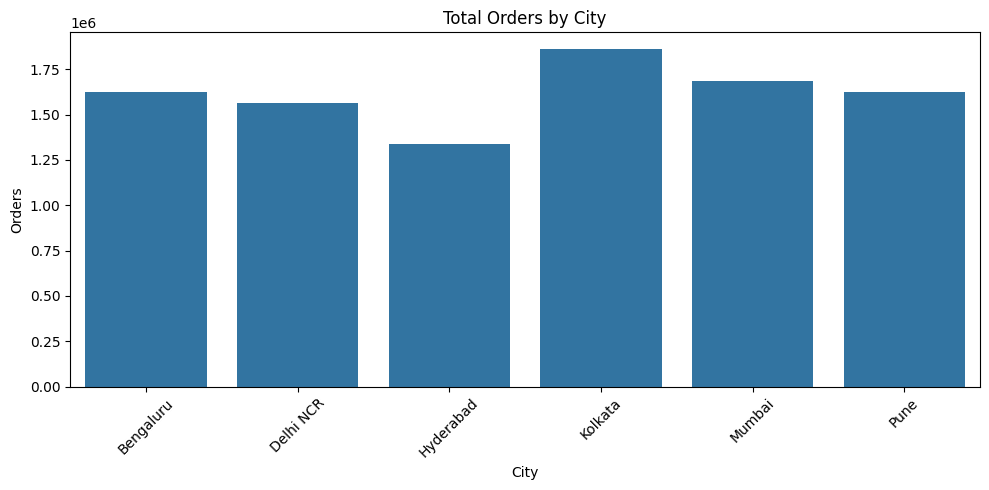

In [40]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=city_summary,
    x="City",
    y="Orders"
)

plt.title("Total Orders by City")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

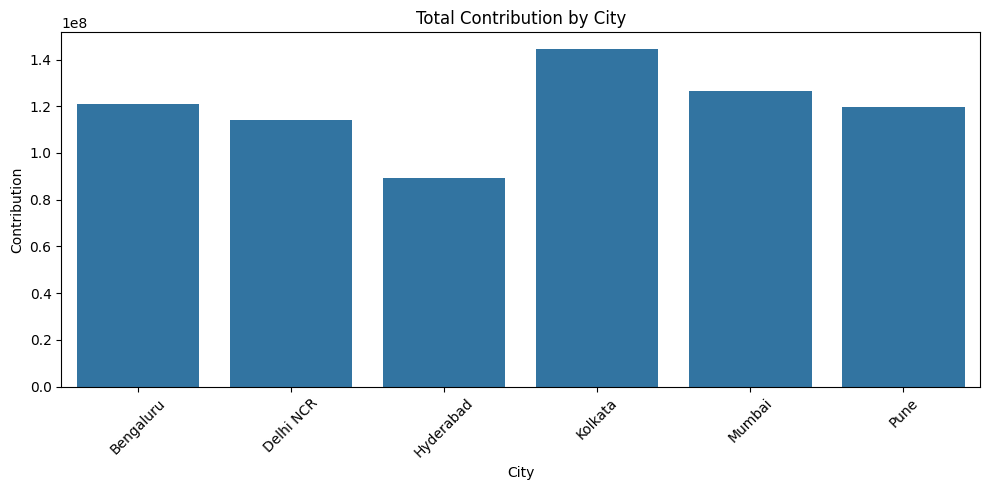

In [41]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=city_summary,
    x="City",
    y="Contribution"
)

plt.title("Total Contribution by City")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

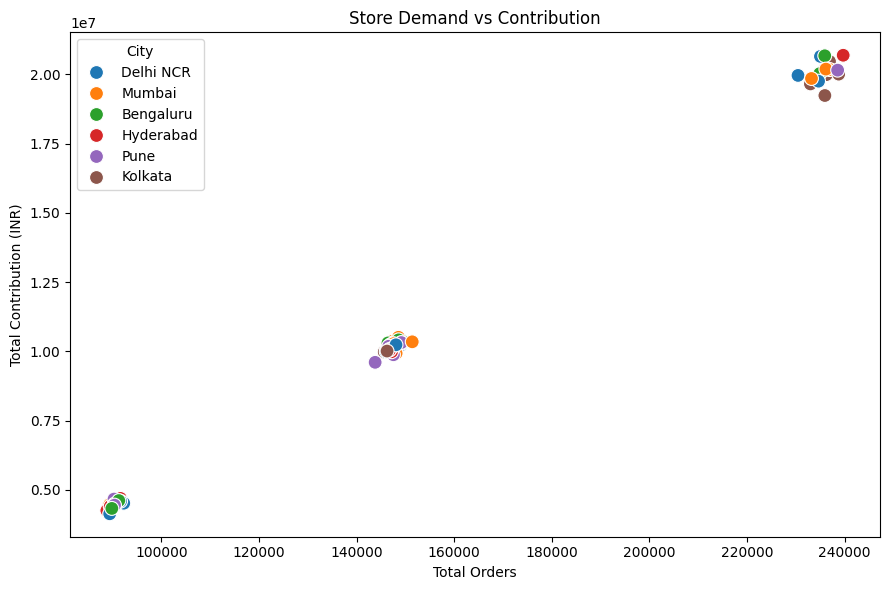

In [42]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=store_summary,
    x="Orders",
    y="Contribution",
    hue="City",
    s=100
)

plt.title("Store Demand vs Contribution")
plt.xlabel("Total Orders")
plt.ylabel("Total Contribution (INR)")
plt.tight_layout()
plt.show()

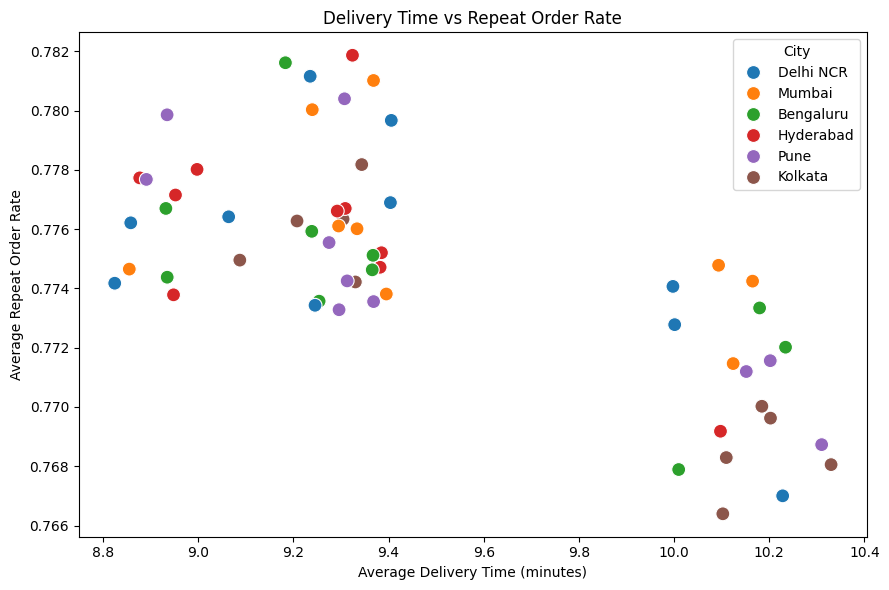

In [43]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=store_summary,
    x="Avg_Delivery_Time",
    y="Avg_Repeat",
    hue="City",
    s=100
)

plt.title("Delivery Time vs Repeat Order Rate")
plt.xlabel("Average Delivery Time (minutes)")
plt.ylabel("Average Repeat Order Rate")

plt.tight_layout()
plt.show()

Correlation analysis

In [44]:
correlation_columns = [
    "Orders",
    "Conversion_Rate",
    "Average_Order_Value_INR",
    "Discounts_INR",
    "Delivery_Time_Min",
    "Promised_Time_Hit_Rate",
    "In_Stock_Rate",
    "Stockout_Events",
    "Cancellation_Rate",
    "Complaint_Rate",
    "Repeat_Order_Rate",
    "Delivery_Cost_INR",
    "Store_Variable_Cost_INR",
    "Contribution_INR",
    "Contribution_Per_Order_INR",
    "Capacity_Utilisation_Rate"
]

corr_matrix = analysis_df[
    correlation_columns
].corr()

corr_matrix

,Orders,Conversion_Rate,Average_Order_Value_INR,Discounts_INR,Delivery_Time_Min,Promised_Time_Hit_Rate,In_Stock_Rate,Stockout_Events,Cancellation_Rate,Complaint_Rate,Repeat_Order_Rate,Delivery_Cost_INR,Store_Variable_Cost_INR,Contribution_INR,Contribution_Per_Order_INR,Capacity_Utilisation_Rate
Orders,1.000000,0.624652,0.171549,0.705425,0.391416,-0.567083,-0.334167,0.781067,0.273847,0.248580,-0.081827,0.903300,0.301367,0.838814,0.454839,0.860664
Conversion_Rate,0.624652,1.000000,0.092598,0.473891,0.294008,-0.429039,-0.264080,0.514276,0.205530,0.182977,-0.062200,0.567577,0.173887,0.512997,0.272785,0.699815
Average_Order_Value_INR,0.171549,0.092598,1.000000,0.378210,0.051380,-0.077822,-0.041033,0.126415,0.036513,0.041051,-0.022218,0.154523,0.072410,0.473870,0.616573,0.108902
Discounts_INR,0.705425,0.473891,0.378210,1.000000,0.285881,-0.409044,-0.236089,0.555547,0.203053,0.186799,-0.091998,0.639543,0.217179,0.639546,0.377920,0.615431
Delivery_Time_Min,0.391416,0.294008,0.051380,0.285881,1.000000,-0.852197,-0.182961,0.334444,0.531509,0.533170,-0.194712,0.352037,0.115439,0.294471,0.118000,0.417572
Promised_Time_Hit_Rate,-0.567083,-0.429039,-0.077822,-0.409044,-0.852197,1.000000,0.258304,-0.480503,-0.496629,-0.483571,0.177215,-0.511038,-0.159004,-0.446187,-0.201921,-0.605806
In_Stock_Rate,-0.334167,-0.264080,-0.041033,-0.236089,-0.182961,0.258304,1.000000,-0.727597,-0.307062,-0.154841,0.066558,-0.309610,-0.049325,-0.269755,-0.148580,-0.385832
Stockout_Events,0.781067,0.514276,0.126415,0.555547,0.334444,-0.480503,-0.727597,1.000000,0.379004,0.246989,-0.095217,0.710725,0.217423,0.647330,0.336615,0.709213
Cancellation_Rate,0.273847,0.205530,0.036513,0.203053,0.531509,-0.496629,-0.307062,0.379004,1.000000,0.574630,-0.240608,0.248507,0.066186,0.186597,0.051788,0.291200
Complaint_Rate,0.248580,0.182977,0.041051,0.186799,0.533170,-0.483571,-0.154841,0.246989,0.574630,1.000000,-0.230787,0.225089,0.072297,0.163218,0.038938,0.257362


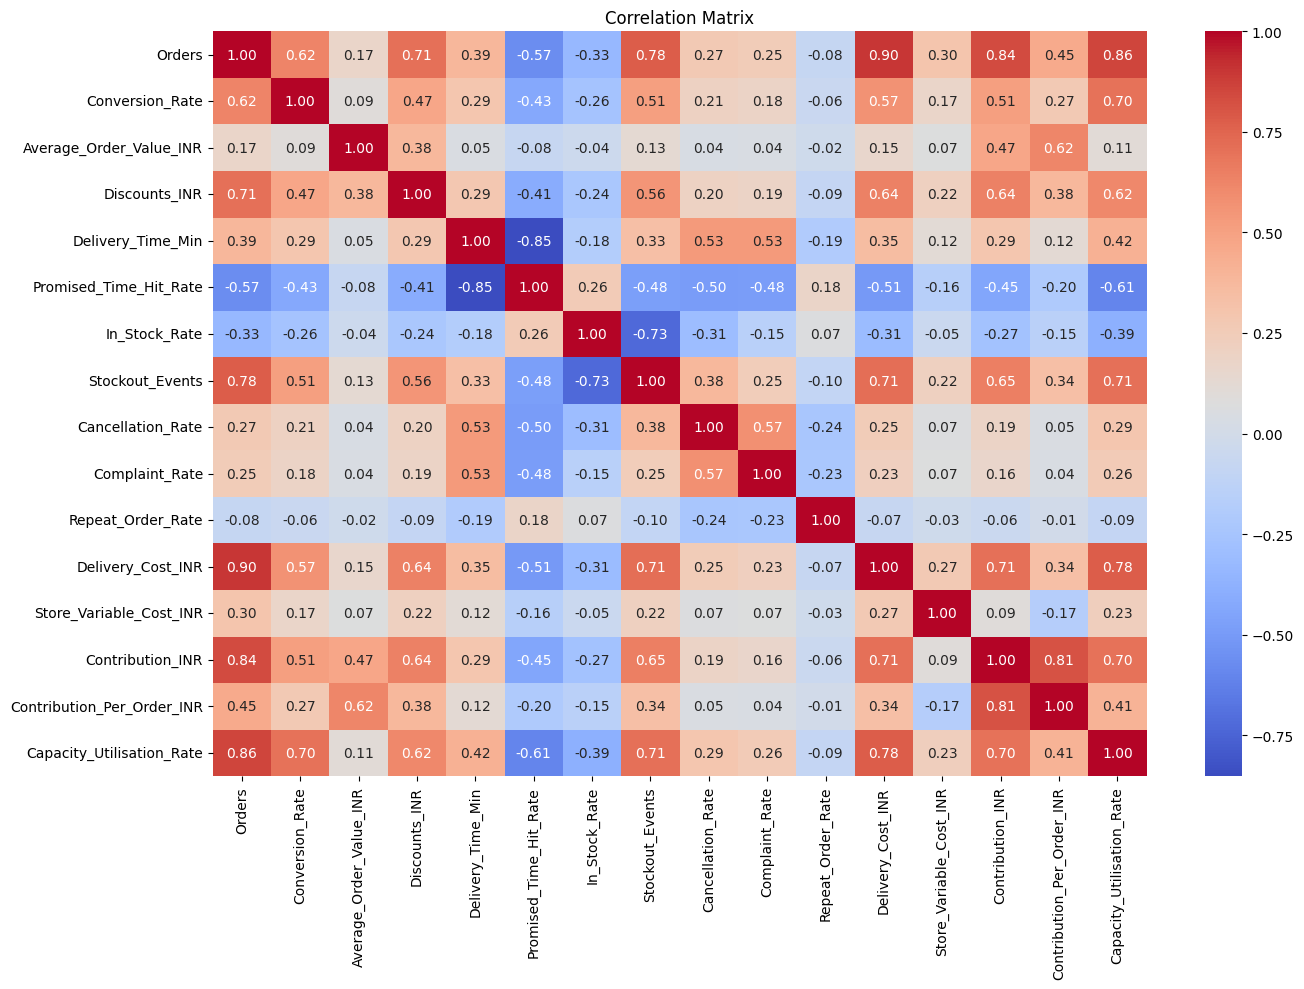

In [45]:
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

Hypothesis Test 1

In [46]:
median_delivery = store_summary[
    "Avg_Delivery_Time"
].median()

print("Median delivery time:",
      median_delivery)

Median delivery time: 9.32715187017509


In [47]:
store_summary["Delivery_Group"] = np.where(
    store_summary["Avg_Delivery_Time"] <= median_delivery,
    "Fast",
    "Slow"
)

store_summary.groupby(
    "Delivery_Group"
)["Avg_Repeat"].describe()

,count,mean,std,min,25%,50%,75%,max
Delivery_Group,,,,,,,,
Fast,30.0,0.776714,0.002477,0.773281,0.774727,0.776377,0.777716,0.781866
Slow,30.0,0.772789,0.003694,0.766397,0.769724,0.773449,0.774764,0.781015


In [48]:
fast = store_summary[
    store_summary["Delivery_Group"] == "Fast"
]["Avg_Repeat"]

slow = store_summary[
    store_summary["Delivery_Group"] == "Slow"
]["Avg_Repeat"]

t_stat, p_value = stats.ttest_ind(
    fast,
    slow,
    equal_var=False
)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 4.833605068551726
p-value: 1.2853303912439364e-05


In [50]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0: statistically significant difference.")
else:
    print("Fail to reject H0: no statistically significant difference.")

Reject H0: statistically significant difference.


Hypothesis Test 2

In [51]:
stockout_corr, stockout_p = stats.pearsonr(
    store_summary["Avg_InStock"],
    store_summary["Avg_Repeat"]
)

print("Correlation:", stockout_corr)
print("p-value:", stockout_p)

Correlation: 0.6821227222322719
p-value: 1.95850232449917e-09


Hypothesis Test 3

In [52]:
maturity_corr, maturity_p = stats.pearsonr(
    analysis_df["Maturity_Months"],
    analysis_df["Contribution_Per_Order_INR"]
)

print("Correlation:", maturity_corr)
print("p-value:", maturity_p)

Correlation: 0.047483218793177295
p-value: 8.051634219994796e-18


Regression: Contribution drivers

In [53]:
model_df = analysis_df[
    [
        "Contribution_Per_Order_INR",
        "Average_Order_Value_INR",
        "Discount_Rate",
        "Delivery_Cost_Per_Order",
        "In_Stock_Rate",
        "Delivery_Time_Min",
        "Capacity_Utilisation_Rate",
        "Maturity_Months"
    ]
].dropna()

model_df.head()

,Contribution_Per_Order_INR,Average_Order_Value_INR,Discount_Rate,Delivery_Cost_Per_Order,In_Stock_Rate,Delivery_Time_Min,Capacity_Utilisation_Rate,Maturity_Months
0,70.546029,709.303350,0.092647,42.598993,0.960303,8.023591,0.861290,32
1,67.902099,621.855739,0.036116,30.965482,0.946038,7.477917,0.809091,8
2,65.595479,649.966202,0.028669,32.686596,0.925030,7.581074,0.845161,22
3,30.694711,518.504106,0.115637,33.669285,0.946752,11.377813,1.000000,44
4,96.881234,771.032033,0.075142,42.822127,0.931838,9.602919,1.017949,31


Train/test split

In [54]:
X = model_df.drop(
    columns=["Contribution_Per_Order_INR"]
)

y = model_df[
    "Contribution_Per_Order_INR"
]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 26208
Testing rows: 6552


Train regression model

In [55]:
model = LinearRegression()

model.fit(
    X_train,
    y_train
)

LinearRegression()

In [56]:
y_pred = model.predict(X_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R²:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

R²: 0.5725379196805013
MAE: 15.817307703076958
RMSE: 19.609998388585506


In [57]:
coefficients = pd.DataFrame({
    "Variable": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(
    "Coefficient",
    ascending=False
)

,Variable,Coefficient
5,Capacity_Utilisation_Rate,53.639777
3,In_Stock_Rate,9.109684
0,Average_Order_Value_INR,0.200017
6,Maturity_Months,0.046563
2,Delivery_Cost_Per_Order,-0.978245
4,Delivery_Time_Min,-1.031278
1,Discount_Rate,-205.374275


In [58]:
X_sm = sm.add_constant(X)

ols_model = sm.OLS(
    y,
    X_sm
).fit()

print(ols_model.summary())

                                OLS Regression Results                                
Dep. Variable:     Contribution_Per_Order_INR   R-squared:                       0.570
Model:                                    OLS   Adj. R-squared:                  0.570
Method:                         Least Squares   F-statistic:                     6195.
Date:                        Thu, 10 Sep 2026   Prob (F-statistic):               0.00
Time:                                15:48:08   Log-Likelihood:            -1.4424e+05
No. Observations:                       32760   AIC:                         2.885e+05
Df Residuals:                           32752   BIC:                         2.886e+05
Df Model:                                   7                                         
Covariance Type:                    nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------

Repeat behaviour model

In [59]:
repeat_df = analysis_df[
    [
        "Repeat_Order_Rate",
        "Delivery_Time_Min",
        "In_Stock_Rate",
        "Cancellation_Rate",
        "Complaint_Rate",
        "Promised_Time_Hit_Rate",
        "Discount_Rate",
        "Maturity_Months"
    ]
].dropna()

X_repeat = repeat_df.drop(
    columns=["Repeat_Order_Rate"]
)

y_repeat = repeat_df[
    "Repeat_Order_Rate"
]

In [60]:
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_repeat,
    y_repeat,
    test_size=0.20,
    random_state=42
)

repeat_model = LinearRegression()

repeat_model.fit(
    X_train_r,
    y_train_r
)

y_pred_r = repeat_model.predict(
    X_test_r
)

In [61]:
print(
    "R²:",
    r2_score(y_test_r, y_pred_r)
)

print(
    "MAE:",
    mean_absolute_error(y_test_r, y_pred_r)
)

print(
    "RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test_r,
            y_pred_r
        )
    )
)

R²: 0.07942480699102106
MAE: 0.043626571115157234
RMSE: 0.05464901275209714


Store segmentation

In [62]:
store_summary["Demand_Leader"] = (
    store_summary["Orders"]
    >= store_summary["Orders"].quantile(0.75)
)

store_summary["Service_Risk"] = (
    (store_summary["Avg_Promised_Hit"] <
     store_summary["Avg_Promised_Hit"].quantile(0.25))
    |
    (store_summary["Avg_Delivery_Time"] >
     store_summary["Avg_Delivery_Time"].quantile(0.75))
)

store_summary["Inventory_Risk"] = (
    store_summary["Avg_InStock"] <
    store_summary["Avg_InStock"].quantile(0.25)
)

store_summary["Economic_Laggard"] = (
    store_summary["Avg_Contribution_Per_Order"] <
    store_summary[
        "Avg_Contribution_Per_Order"
    ].quantile(0.25)
)

In [63]:
store_summary[
    [
        "Store_ID",
        "City",
        "Demand_Leader",
        "Service_Risk",
        "Inventory_Risk",
        "Economic_Laggard"
    ]
].head(20)

,Store_ID,City,Demand_Leader,Service_Risk,Inventory_Risk,Economic_Laggard
0,DS001,Delhi NCR,False,False,False,False
1,DS002,Mumbai,False,False,False,True
2,DS003,Bengaluru,False,False,False,False
3,DS004,Hyderabad,False,False,False,False
4,DS005,Pune,True,True,True,False
5,DS006,Kolkata,True,True,True,False
6,DS007,Delhi NCR,False,False,True,False
7,DS008,Mumbai,False,False,False,False
8,DS009,Bengaluru,False,False,False,False
9,DS010,Hyderabad,False,False,False,True


Exception stores

In [64]:
exception_stores = store_summary[
    (
        store_summary["Service_Risk"]
        |
        store_summary["Inventory_Risk"]
        |
        store_summary["Economic_Laggard"]
    )
].copy()

exception_stores[
    [
        "Store_ID",
        "City",
        "Orders",
        "Avg_Delivery_Time",
        "Avg_InStock",
        "Avg_Contribution_Per_Order",
        "Avg_Repeat"
    ]
].sort_values(
    "Avg_Contribution_Per_Order"
).head(20)

,Store_ID,City,Orders,Avg_Delivery_Time,Avg_InStock,Avg_Contribution_Per_Order,Avg_Repeat
42,DS043,Delhi NCR,89423,8.824403,0.952029,43.319199,0.774176
56,DS057,Bengaluru,89866,8.934694,0.952021,45.128854,0.774378
21,DS022,Hyderabad,88840,8.952114,0.950982,45.755236,0.777151
18,DS019,Delhi NCR,92307,9.063912,0.951519,46.389002,0.776416
52,DS053,Pune,90409,8.890923,0.950774,46.700277,0.777678
27,DS028,Hyderabad,89536,8.876953,0.952466,46.711468,0.777729
1,DS002,Mumbai,89407,8.855024,0.951658,47.593536,0.774652
36,DS037,Delhi NCR,91651,8.858112,0.950541,47.695261,0.776213
45,DS046,Hyderabad,90424,8.997446,0.952015,47.861687,0.778016
41,DS042,Kolkata,90617,9.087371,0.952600,47.868674,0.774955


Final store classification

In [65]:
def classify_store(row):

    strong_demand = row["Demand_Leader"]
    good_service = not row["Service_Risk"]
    good_inventory = not row["Inventory_Risk"]
    good_economics = not row["Economic_Laggard"]

    if strong_demand and good_service and good_inventory and good_economics:
        return "Expand"

    elif strong_demand and (
        row["Service_Risk"]
        or row["Inventory_Risk"]
        or row["Economic_Laggard"]
    ):
        return "Optimise"

    elif (
        row["Orders"] < store_summary["Orders"].median()
        and row["Avg_Capacity"] < store_summary["Avg_Capacity"].median()
    ):
        return "Consolidate"

    elif row["Economic_Laggard"] and row["Service_Risk"]:
        return "Pause"

    else:
        return "Optimise"

In [66]:
store_summary["Decision"] = store_summary.apply(
    classify_store,
    axis=1
)

store_summary[
    [
        "Store_ID",
        "City",
        "Decision"
    ]
].sort_values("Decision")

,Store_ID,City,Decision
59,DS060,Kolkata,Consolidate
34,DS035,Pune,Consolidate
39,DS040,Hyderabad,Consolidate
41,DS042,Kolkata,Consolidate
42,DS043,Delhi NCR,Consolidate
43,DS044,Mumbai,Consolidate
28,DS029,Pune,Consolidate
27,DS028,Hyderabad,Consolidate
44,DS045,Bengaluru,Consolidate
45,DS046,Hyderabad,Consolidate


Decision count

In [67]:
store_summary["Decision"].value_counts()

Decision
Optimise       31
Consolidate    29
Name: count, dtype: int64

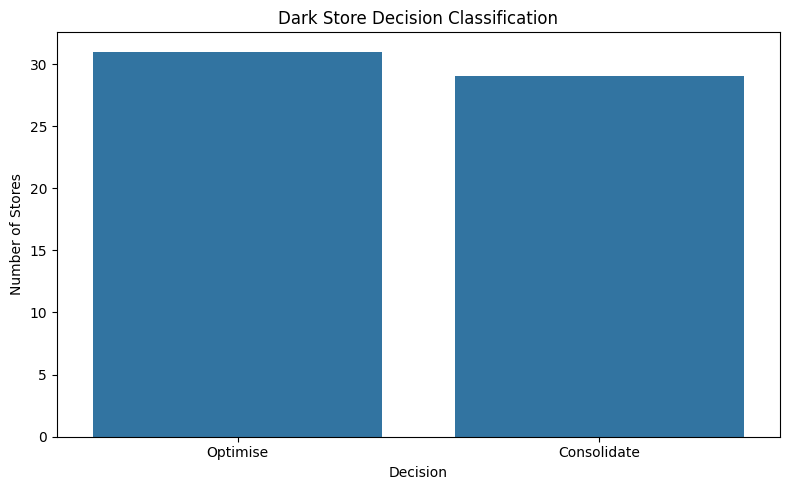

In [68]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=store_summary,
    x="Decision"
)

plt.title("Dark Store Decision Classification")
plt.xlabel("Decision")
plt.ylabel("Number of Stores")

plt.tight_layout()
plt.show()

Final management table

In [69]:
final_store_view = store_summary[
    [
        "Store_ID",
        "City",
        "Store_Format",
        "Orders",
        "Contribution",
        "Avg_Repeat",
        "Avg_InStock",
        "Avg_Promised_Hit",
        "Avg_Delivery_Time",
        "Avg_Cancellation",
        "Avg_Complaint",
        "Avg_Capacity",
        "Avg_Contribution_Per_Order",
        "Demand_Leader",
        "Service_Risk",
        "Inventory_Risk",
        "Economic_Laggard",
        "Decision"
    ]
].sort_values(
    ["Decision", "Contribution"],
    ascending=[True, False]
)

final_store_view

,Store_ID,City,Store_Format,Orders,Contribution,Avg_Repeat,Avg_InStock,Avg_Promised_Hit,Avg_Delivery_Time,Avg_Cancellation,Avg_Complaint,Avg_Capacity,Avg_Contribution_Per_Order,Demand_Leader,Service_Risk,Inventory_Risk,Economic_Laggard,Decision
7,DS008,Mumbai,Mature Mixed,147230,1.035933e+07,0.776628,0.947445,0.891450,9.292712,0.029864,0.015488,0.861255,69.050714,False,False,False,False,Consolidate
8,DS009,Bengaluru,Mature Mixed,146446,1.030551e+07,0.775926,0.947715,0.889227,9.238625,0.030024,0.014876,0.857943,68.849784,False,False,False,False,Consolidate
43,DS044,Mumbai,Mature Mixed,147580,1.027879e+07,0.773812,0.947661,0.885921,9.395241,0.030472,0.015805,0.861763,67.893897,False,False,False,False,Consolidate
19,DS020,Mumbai,Mature Mixed,146944,1.022908e+07,0.780030,0.947722,0.891410,9.239606,0.028694,0.014763,0.857081,67.929729,False,False,False,False,Consolidate
44,DS045,Bengaluru,Mature Mixed,147456,1.019032e+07,0.781613,0.948611,0.891579,9.183173,0.029268,0.014810,0.861553,67.786085,False,False,False,False,Consolidate
46,DS047,Pune,Mature Mixed,146607,1.018609e+07,0.774254,0.948605,0.890971,9.312963,0.029867,0.015818,0.859090,68.177866,False,False,False,False,Consolidate
14,DS015,Bengaluru,Mature Mixed,147251,1.015582e+07,0.774627,0.948339,0.886971,9.365669,0.030409,0.015417,0.860623,67.698484,False,False,False,False,Consolidate
48,DS049,Delhi NCR,Mature Mixed,146825,1.007744e+07,0.776895,0.946910,0.886550,9.403896,0.029867,0.015656,0.860942,67.416953,False,False,False,False,Consolidate
51,DS052,Hyderabad,Mature Mixed,146769,1.004756e+07,0.776610,0.948382,0.890729,9.292088,0.028341,0.014779,0.858200,67.263836,False,False,False,False,Consolidate
16,DS017,Pune,Mature Mixed,146139,1.004164e+07,0.773281,0.948618,0.888854,9.295918,0.029260,0.015155,0.851778,67.501442,False,False,False,False,Consolidate


Export results to Excel

In [70]:
output_file = "Blinkit_Analytics_Results.xlsx"

with pd.ExcelWriter(output_file, engine="openpyxl") as writer:

    network_summary.to_excel(
        writer,
        sheet_name="Network_Summary",
        index=False
    )

    city_summary.to_excel(
        writer,
        sheet_name="City_Summary",
        index=False
    )

    store_summary.to_excel(
        writer,
        sheet_name="Store_Summary",
        index=False
    )

    final_store_view.to_excel(
        writer,
        sheet_name="Final_Decisions",
        index=False
    )

    coefficients.to_excel(
        writer,
        sheet_name="Contribution_Model",
        index=False
    )

print("Exported:", output_file)

Exported: Blinkit_Analytics_Results.xlsx
